# 02 - Pré-processamento de Dados
## Tech Challenge Fase 1 - Saúde e Segurança da Mulher
**Responsável:** Natalia Cabrera

---

### Objetivo
Aplicar o pipeline de pré-processamento nos dados, preparando-os para a modelagem de Machine Learning.

In [1]:
# =========================
# IMPORTS
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

## 1. Carregamento do Dataset

In [3]:
# =========================
# CARREGAMENTO DOS DADOS
# =========================

df = pd.read_csv('../../src/Clinico.csv')

print("="*70)
print("DATASET CLÍNICO CARREGADO")
print("="*70)

print(f"\n📊 Shape: {df.shape}")
print(f"\n📋 Colunas:\n{df.columns.tolist()}")
print(f"\n🔎 Amostra:")
print(df.head())

DATASET CLÍNICO CARREGADO

📊 Shape: (4024, 16)

📋 Colunas:
['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status', 'Progesterone Status', 'Regional Node Examined', 'Reginol Node Positive', 'Survival Months', 'Status']

🔎 Amostra:
   Age   Race Marital Status T Stage  N Stage 6th Stage  \
0   68  White        Married       T1      N1       IIA   
1   50  White        Married       T2      N2      IIIA   
2   58  White       Divorced       T3      N3      IIIC   
3   58  White        Married       T1      N1       IIA   
4   47  White        Married       T2      N1       IIB   

               differentiate Grade   A Stage  Tumor Size Estrogen Status  \
0      Poorly differentiated     3  Regional           4        Positive   
1  Moderately differentiated     2  Regional          35        Positive   
2  Moderately differentiated     2  Regional          63        Positive   
3      Poorly differentiate

## 2. Identificação de variaveis

In [4]:
# =========================
# IDENTIFICAÇÃO DE VARIÁVEIS
# =========================

print("\n" + "="*70)
print("ANÁLISE DE VARIÁVEIS")
print("="*70)

categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n✓ Variáveis categóricas: {categorical_cols}")
print(f"✓ Variáveis numéricas: {len(numeric_cols)}")


ANÁLISE DE VARIÁVEIS

✓ Variáveis categóricas: ['Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Estrogen Status', 'Progesterone Status', 'Status']
✓ Variáveis numéricas: 5


C:\Users\nacab\AppData\Local\Temp\ipykernel_19228\415847069.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


## 3. LABEL ENCODING


In [5]:
# =========================
# LABEL ENCODING
# =========================

print("\n" + "="*70)
print("APLICANDO LABEL ENCODING")
print("="*70)

df_encoded = df.copy()

if 'Status' not in df.columns:
    raise ValueError("Coluna 'Status' não encontrada no dataset")

le = LabelEncoder()
df_encoded['Status_encoded'] = le.fit_transform(df_encoded['Status'])

encoding_map = dict(zip(le.classes_, le.transform(le.classes_)))

print("\n📌 Mapeamento:")
for k, v in encoding_map.items():
    print(f"  {k} → {v}")

print(f"\nDistribuição:")
print(df_encoded['Status_encoded'].value_counts())


APLICANDO LABEL ENCODING

📌 Mapeamento:
  Alive → 0
  Dead → 1

Distribuição:
Status_encoded
0    3408
1     616
Name: count, dtype: int64


## 4. LIMPEZA DE DADOS

In [6]:
# =========================
# LIMPEZA DE DADOS
# =========================

print("\n" + "="*70)
print("LIMPEZA DE DADOS")
print("="*70)

df_cleaned = df_encoded.copy()

# Remover duplicatas
duplicates = df_cleaned.duplicated().sum()
if duplicates > 0:
    df_cleaned.drop_duplicates(inplace=True)
    print(f"✓ Removidas {duplicates} duplicatas")
else:
    print("✓ Nenhuma duplicata encontrada")

# Valores ausentes
missing = df_cleaned.isnull().sum().sum()
if missing > 0:
    print(f"✓ Tratando {missing} valores ausentes")
    
    for col in df_cleaned.select_dtypes(include=[np.number]):
        df_cleaned[col].fillna(df_cleaned[col].median(), inplace=True)
        
    for col in df_cleaned.select_dtypes(include=['object']):
        df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)
else:
    print("✓ Sem valores ausentes")

# Valores negativos
num_cols = df_cleaned.select_dtypes(include=[np.number]).columns
neg_mask = (df_cleaned[num_cols] < 0).any(axis=1)

if neg_mask.sum() > 0:
    df_cleaned = df_cleaned[~neg_mask]
    print(f"✓ Removidas {neg_mask.sum()} linhas com valores negativos")
else:
    print("✓ Sem valores negativos")


LIMPEZA DE DADOS
✓ Removidas 1 duplicatas
✓ Sem valores ausentes
✓ Sem valores negativos


## 5. NORMALIZAÇÃO (STANDARD SCALER)

In [7]:
# =========================
# NORMALIZAÇÃO
# =========================

print("\n" + "="*70)
print("APLICANDO STANDARD SCALER")
print("="*70)

df_scaled = df_cleaned.copy()

numeric_features = df_scaled.select_dtypes(include=[np.number]).columns
numeric_features = [col for col in numeric_features if col != 'Status_encoded']

scaler = StandardScaler()
df_scaled[numeric_features] = scaler.fit_transform(df_scaled[numeric_features])

print(f"\n✓ {len(numeric_features)} features normalizadas")


APLICANDO STANDARD SCALER

✓ 5 features normalizadas


## 6. CORRELAÇÃO


ANÁLISE DE CORRELAÇÃO

📊 Total de features numéricas: 6


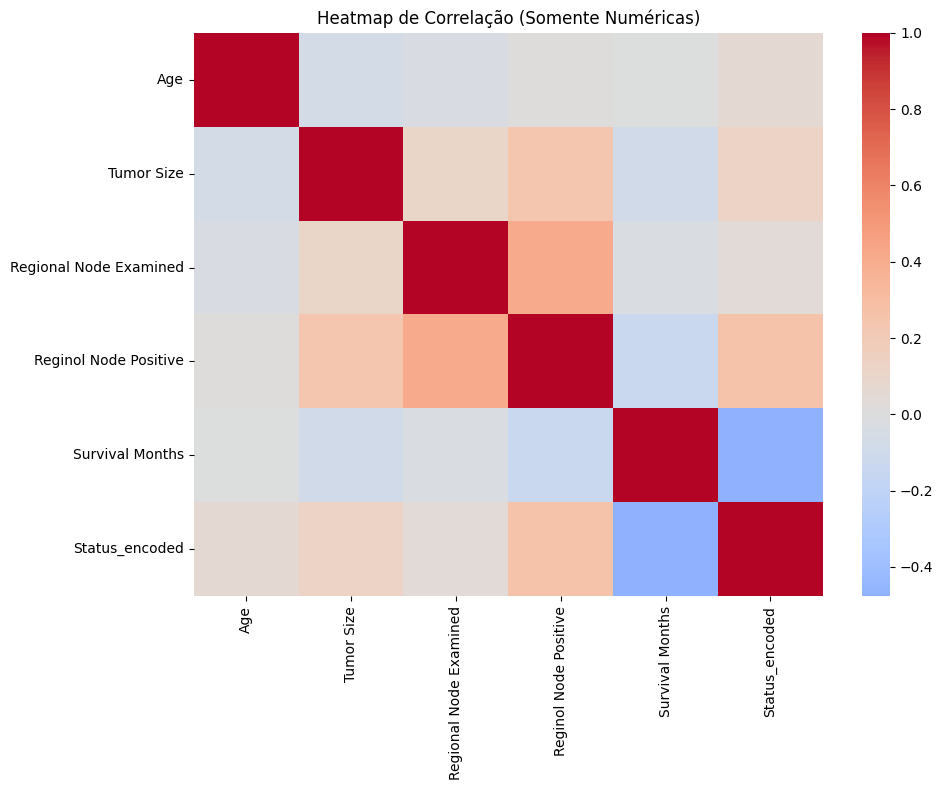


✅ Correlação calculada com sucesso!


In [9]:
# =========================
# CORRELAÇÃO (APENAS NUMÉRICOS)
# =========================

print("\n" + "="*70)
print("ANÁLISE DE CORRELAÇÃO")
print("="*70)

# Selecionar apenas colunas numéricas
numeric_df = df_scaled.select_dtypes(include=[np.number])

print(f"\n📊 Total de features numéricas: {numeric_df.shape[1]}")

# Calcular correlação
corr = numeric_df.corr()

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax)
plt.title('Heatmap de Correlação (Somente Numéricas)')
plt.tight_layout()
plt.show()

print("\n✅ Correlação calculada com sucesso!")

## 7. Conclusão

In [10]:
# =========================
# DATASET FINAL
# =========================

df_final = df_scaled.copy()

print("\n" + "="*70)
print("DATASET PRONTO PARA MODELAGEM")
print("="*70)

print(f"\n📊 Shape final: {df_final.shape}")
print("\n✅ Preprocessing concluído com sucesso!")


DATASET PRONTO PARA MODELAGEM

📊 Shape final: (4023, 17)

✅ Preprocessing concluído com sucesso!
